In [82]:
import os, glob, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import cfgrib
import xarray as xr

In [ ]:
path          = 'C:\\Users\\maili\\Desktop\\KU\\AppMachineLearning\\Final_Project\\data\\'
MODEL_PATH    = 'saved_models/best_precip_model_2015_2026.pt'
LAG           = 12
HORIZON       = 1
FINAL_EPOCHS  = 15
BATCH         =  128 # 128
SEED          = 42
RAIN_THRESH   = 0.1   # mm — threshold for "raining"
TARGET_HOUR   = 17    # predict precipitation at 17:00 next day
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [99]:
# load in ds0 and ds1 for all years, then concatenate along time dimension
ds0 = xr.open_dataset("data\\ds0_all_years_deacc.nc")
ds1 = xr.open_dataset("data\\ds1_all_years_deacc.nc")

In [100]:
tp_aligned   = np.nan_to_num(tp_aligned,   nan=0.0)
ssrd_aligned = np.nan_to_num(ssrd_aligned, nan=0.0)

print("tp_aligned NaNs after fix:", np.isnan(tp_aligned).sum())
print("tp_aligned max:", tp_aligned.max() * 1000, "mm")

tp_aligned NaNs after fix: 0
tp_aligned max: 12.801647 mm


In [101]:
N_valid    = len(ds0.time) - HORIZON
ds0_time   = ds0.time.values

# target: tp at T+24h in mm
y_raw_mm = tp_aligned[HORIZON:].astype(np.float32) * 1000

# input channels
channels, chan_names = [], []
for var in ['sp', 'tcc', 'u10', 'v10', 't2m']:
    channels.append(ds0[var].values[:N_valid].astype(np.float32))
    chan_names.append(var)
channels.append(tp_aligned[:N_valid].astype(np.float32) * 1000)
chan_names.append("tp")
channels.append(ssrd_aligned[:N_valid].astype(np.float32))
chan_names.append("ssrd")

ref_time   = ds0_time[:N_valid]
N_FEATURES = len(channels)

print(f"N_valid: {N_valid}")
print(f"Target range: {y_raw_mm.min():.4f} – {y_raw_mm.max():.4f} mm")
print(f"Target NaNs: {np.isnan(y_raw_mm).sum()}")
for name, ch in zip(chan_names, channels):
    print(f"  {name}: {ch.shape}")

N_valid: 96623
Target range: 0.0000 – 12.8016 mm
Target NaNs: 0
  sp: (96623, 5, 5)
  tcc: (96623, 5, 5)
  u10: (96623, 5, 5)
  v10: (96623, 5, 5)
  t2m: (96623, 5, 5)
  tp: (96623, 5, 5)
  ssrd: (96623, 5, 5)


In [102]:
# ── log transform & stack
X_raw = np.stack(channels, axis=1).astype(np.float32)   # (96600, 7, 5, 5)
y_raw = np.log1p(y_raw_mm)                               # (96600, 5, 5)

tp_idx   = chan_names.index("tp")
ssrd_idx = chan_names.index("ssrd")
X_raw[:, tp_idx] = np.log1p(X_raw[:, tp_idx])
ssrd_mean = X_raw[:, ssrd_idx].mean()
ssrd_std  = X_raw[:, ssrd_idx].std() + 1e-8
X_raw[:, ssrd_idx] = (X_raw[:, ssrd_idx] - ssrd_mean) / ssrd_std

print(f"X_raw: {X_raw.shape} | y_raw: {y_raw.shape}")
print(f"y_raw range: {y_raw.min():.4f} – {y_raw.max():.4f}")
print(f"X_raw NaNs: {np.isnan(X_raw).sum()} | y_raw NaNs: {np.isnan(y_raw).sum()}")


X_raw: (96623, 7, 5, 5) | y_raw: (96623, 5, 5)
y_raw range: 0.0000 – 2.6248
X_raw NaNs: 0 | y_raw NaNs: 0


In [103]:
def make_windows(X, y, lag=LAG):
    idx = np.arange(lag, len(X))
    Xw  = np.stack([X[i-lag:i] for i in idx]).astype(np.float32)
    yw  = y[idx].astype(np.float32)
    return Xw, yw

X_all_w, y_all = make_windows(X_raw, y_raw)
print(f"Windows: X={X_all_w.shape}, y={y_all.shape}")

# ── split
train_end = int(0.70 * len(X_all_w))
val_end   = int(0.85 * len(X_all_w))
X_train_w, y_train = X_all_w[:train_end],        y_all[:train_end]
X_val_w,   y_val   = X_all_w[train_end:val_end], y_all[train_end:val_end]
X_test_w,  y_test  = X_all_w[val_end:],          y_all[val_end:]


Windows: X=(96611, 12, 7, 5, 5), y=(96611, 5, 5)


In [104]:
# ── scale inputs
scaler  = fit_scale(X_train_w)
X_tr_sc = transform(X_train_w, scaler)
X_va_sc = transform(X_val_w,   scaler)
X_te_sc = transform(X_test_w,  scaler)
y_tr, y_va, y_te = y_train, y_val, y_test

# ── oversample rainy windows  
rain_thresh_mm = 0.1
y_tr_mm = np.expm1(y_tr)

rainy_windows = (y_tr_mm > rain_thresh_mm).any(axis=(1, 2))
rainy_idx     = np.where(rainy_windows)[0]
dry_idx       = np.where(~rainy_windows)[0]

print(f"Rainy windows: {len(rainy_idx)} ({100*len(rainy_idx)/len(y_tr):.1f}%)")
print(f"Dry windows:   {len(dry_idx)}")

OVERSAMPLE    = 2 # double the amount of rainy windows
rainy_idx_rep = np.tile(rainy_idx, OVERSAMPLE)
all_idx       = np.concatenate([dry_idx, rainy_idx_rep])
np.random.shuffle(all_idx)

X_tr_bal = X_tr_sc[all_idx]
y_tr_bal  = y_tr[all_idx]

print(f"Balanced training set: {len(X_tr_bal)} windows")
print(f"Rainy fraction after balancing: {(np.expm1(y_tr_bal) > rain_thresh_mm).any(axis=(1,2)).mean():.3f}")



Rainy windows: 24067 (35.6%)
Dry windows:   43560
Balanced training set: 91694 windows
Rainy fraction after balancing: 0.525


In [105]:

# ── 8. DATASET & LOADER ───────────────────────────────────────────────────────
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def loader(X, y, shuffle):
    return DataLoader(SeqDS(X, y), batch_size=BATCH, shuffle=shuffle,
                      num_workers=0, pin_memory=False)


In [106]:
# ── 9. MODEL ──────────────────────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden):
        super().__init__()
        self.conv = nn.Conv2d(in_ch + hidden, 4 * hidden, 3, padding=1)
        self.hidden = hidden
    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, g, o = gates.chunk(4, dim=1)
        c = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h = torch.sigmoid(o) * torch.tanh(c)
        return h, c
    
class ConvLSTMModel(nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.2):
        super().__init__()
        self.hidden = hidden
        self.cell   = ConvLSTMCell(in_ch, hidden)
        self.norm   = nn.GroupNorm(8, hidden)
        self.drop   = nn.Dropout2d(dropout)
        self.backbone = nn.Sequential(
            nn.Conv2d(hidden,        hidden,      3, padding=1), nn.ReLU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(hidden,        hidden // 2, 3, padding=1), nn.ReLU(),
        )
        self.prob_head   = nn.Conv2d(hidden // 2, 1, 1)
        self.amount_head = nn.Conv2d(hidden // 2, 1, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        h = torch.zeros(B, self.hidden, H, W, device=x.device)
        c = torch.zeros(B, self.hidden, H, W, device=x.device)
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
        h    = self.drop(self.norm(h))
        feat = self.backbone(h)
        prob   = self.prob_head(feat).squeeze(1)    # raw logits, NO sigmoid
        amount = self.amount_head(feat).squeeze(1)
        return prob, amount

In [107]:
RAIN_THRESH_LOG = np.log1p(RAIN_THRESH)

def rain_loss(prob_logits, amount, target):
    rain_mask = (target > RAIN_THRESH_LOG).float()
    bce       = nn.functional.binary_cross_entropy_with_logits(prob_logits, rain_mask)
    weight    = 1.0 + 20.0 * rain_mask
    mse       = (weight * (amount - target) ** 2).mean()
    mae       = (weight * torch.abs(amount - target)).mean()
    amt_loss  = 0.7 * mse + 0.3 * mae
    return bce + amt_loss, bce, amt_loss

In [ ]:
best_hidden  = 32
best_lr      = 1e-4
best_dropout = 0.3

model     = ConvLSTMModel(N_FEATURES, best_hidden, best_dropout).to(device)
opt       = torch.optim.Adam(model.parameters(), lr=best_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min',
                                                        factor=0.5, patience=2)

tr_loader = loader(X_tr_bal, y_tr_bal, True)
va_loader = loader(X_va_sc,  y_va,     False)


best_val, best_state = float("inf"), None
train_losses, val_losses = [], []
PATIENCE, patience_counter = 4, 0
FINAL_EPOCHS = 30


for epoch in range(FINAL_EPOCHS):
    model.train()
    tl = []
    for xb, yb in tr_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        prob, amount = model(xb)
        loss, bce, amt_loss = rain_loss(prob, amount, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tl.append(loss.item())
    train_losses.append(np.mean(tl))

    model.eval()
    vl = []
    with torch.no_grad():
        for xb, yb in va_loader:
            xb, yb = xb.to(device), yb.to(device)
            l, _, _ = rain_loss(*model(xb), yb)
            vl.append(l.item())
    val = np.mean(vl)
    val_losses.append(val)
    scheduler.step(val)

    print(f"Epoch {epoch+1:02d}: train={train_losses[-1]:.5f}, val={val:.5f}")

    if val < best_val:
        best_val   = val
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val:.5f}")

Epoch 01: train=1.00959, val=0.61794
Epoch 02: train=0.82439, val=0.58599
Epoch 03: train=0.79190, val=0.56762
Epoch 04: train=0.77256, val=0.56427
Epoch 05: train=0.75900, val=0.55307
Epoch 06: train=0.75116, val=0.55219
Epoch 07: train=0.74350, val=0.53857
Epoch 08: train=0.73827, val=0.53739
Epoch 09: train=0.73395, val=0.52936
Epoch 10: train=0.72757, val=0.54316
  No improvement (1/4)
Epoch 11: train=0.72610, val=0.53519
  No improvement (2/4)
Epoch 12: train=0.72240, val=0.53401
  No improvement (3/4)
Epoch 13: train=0.71678, val=0.52889
Epoch 14: train=0.71460, val=0.53168
  No improvement (1/4)


In [ ]:
# check if its actually learning

model.eval()
with torch.no_grad():
    xb, yb = next(iter(va_loader))
    xb, yb = xb.to(device), yb.to(device)
    prob_logits, amount = model(xb)
    prob = torch.sigmoid(prob_logits)
    amount_mm = torch.expm1(amount)
    target_mm = torch.expm1(yb)

print("Predicted prob range:", prob.min().item(), "–", prob.max().item())
print("Predicted amount (mm):", amount_mm.min().item(), "–", amount_mm.max().item())
print("Target amount (mm):", target_mm.min().item(), "–", target_mm.max().item())
print("Fraction rainy predicted:", (prob > 0.5).float().mean().item())
print("Fraction rainy in target:", (yb > RAIN_THRESH_LOG).float().mean().item())

Predicted prob range: 0.0154926972463727 – 0.37971314787864685
Predicted amount (mm): 0.07561200857162476 – 0.47145572304725647
Target amount (mm): 0.0 – 0.408172607421875
Fraction rainy predicted: 0.0
Fraction rainy in target: 0.009062499739229679


In [ ]:
model.load_state_dict(best_state)
print(f"\nLoaded best model — val loss: {best_val:.5f}")


Loaded best model — val loss: 0.97373


           TEST SET METRICS
  MAE          : 244.9077 mm
  RMSE         : 348.2406 mm
  Bias         : 126.5606 mm
  Correlation  : 0.1803
---------------------------------------------
  POD (recall) : 1.0000  (fraction of rain events caught)
  FAR          : 0.3718  (fraction of rain alarms that are false)
  CSI          : 0.6282  (overall skill, 1=perfect)


C:\Users\maili\AppData\Local\Temp\ipykernel_30312\3227564480.py:98: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\maili\AppData\Local\Temp\ipykernel_30312\3227564480.py:99: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('evaluation.png', dpi=150)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


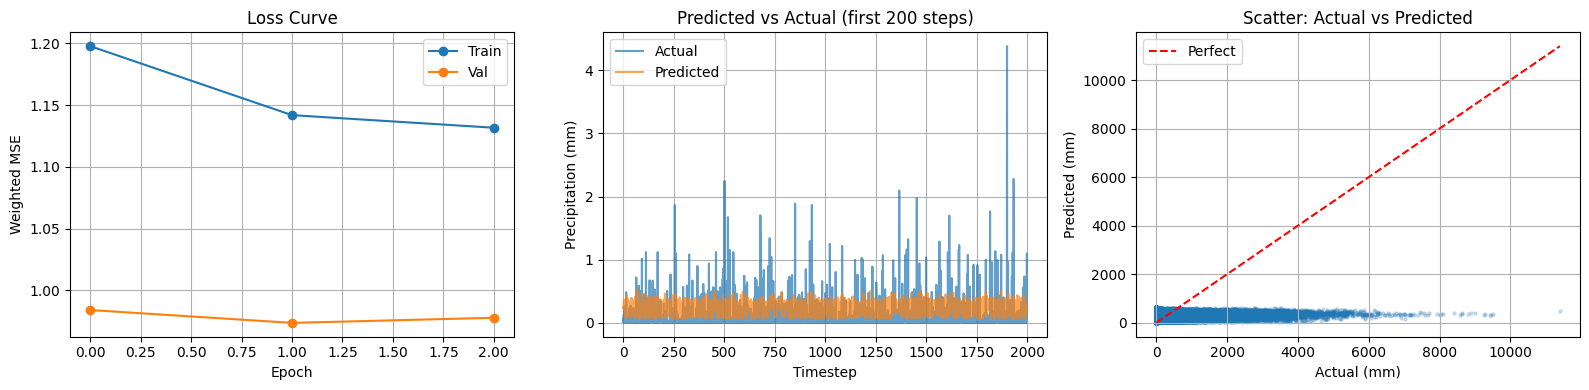

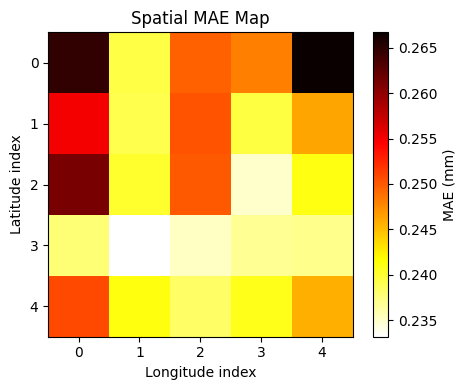

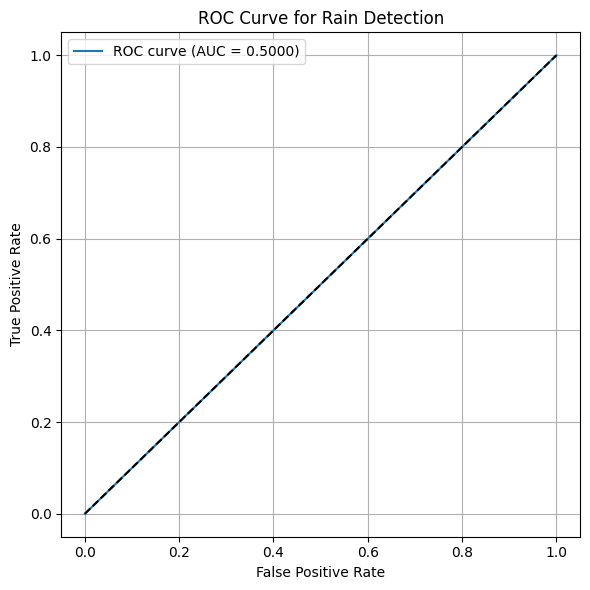

In [ ]:
# ── collect predictions on test set
model.eval()
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
all_probs, all_amounts, all_targets = [], [], []

with torch.no_grad():
    for xb, yb in tr_loader:
        xb = xb.to(device)
        prob_pct = torch.sigmoid(prob_logits) * 100   # 0–100%
        prob_logits, amount = model(xb)
        prob = torch.sigmoid(prob_logits).cpu().numpy()   # (B, H, W) 0-1
        all_probs.append(prob)
        all_amounts.append(amount.cpu().numpy())
        all_targets.append(yb.numpy())

probs   = np.concatenate(all_probs,   axis=0)  # (N, H, W)
amounts = np.concatenate(all_amounts, axis=0)  # (N, H, W)
targets = np.concatenate(all_targets, axis=0)  # (N, H, W)

# ── inverse transform
amounts_mm = np.expm1(amounts)   # back to mm
targets_mm = np.expm1(targets)

# ── for scatter/metrics use amount head
preds_mm   = amounts_mm
preds_flat   = preds_mm.reshape(-1)
targets_flat = targets_mm.reshape(-1)

# ── 1. SCALAR METRICS ─────────────────────────────────────────────────────────
mae  = mean_absolute_error(targets_flat, preds_flat)
rmse = np.sqrt(mean_squared_error(targets_flat, preds_flat))
bias = (preds_flat - targets_flat).mean()

# correlation
corr = np.corrcoef(targets_flat, preds_flat)[0, 1]

# skill scores for rain detection (binary)
threshold = 0.1 / 1000  # 0.1 mm threshold for "rain event"
pred_rain   = preds_flat   > threshold
target_rain = targets_flat > threshold

hits        = (pred_rain  & target_rain).sum()
misses      = (~pred_rain & target_rain).sum()
false_alarm = (pred_rain  & ~target_rain).sum()
correct_neg = (~pred_rain & ~target_rain).sum()

pod  = hits / (hits + misses + 1e-8)          # probability of detection
far  = false_alarm / (hits + false_alarm + 1e-8)  # false alarm ratio
csi  = hits / (hits + misses + false_alarm + 1e-8)  # critical success index

print("=" * 45)
print("           TEST SET METRICS")
print("=" * 45)
print(f"  MAE          : {mae*1000:.4f} mm")
print(f"  RMSE         : {rmse*1000:.4f} mm")
print(f"  Bias         : {bias*1000:.4f} mm")
print(f"  Correlation  : {corr:.4f}")
print("-" * 45)
print(f"  POD (recall) : {pod:.4f}  (fraction of rain events caught)")
print(f"  FAR          : {far:.4f}  (fraction of rain alarms that are false)")
print(f"  CSI          : {csi:.4f}  (overall skill, 1=perfect)")
print("=" * 45)

# ── 2. TRAINING CURVE ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_losses, label='Train', marker='o')
axes[0].plot(val_losses,   label='Val',   marker='o')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted MSE')
axes[0].legend()
axes[0].grid(True)

# ── 3. PREDICTED VS ACTUAL (spatial mean over grid) ───────────────────────────
pred_ts   = preds_mm.mean(axis=(1,2))      # mean over 5×5 grid → mm
target_ts = targets_mm.mean(axis=(1,2)) 

axes[1].plot(target_ts[:2000], label='Actual',    alpha=0.7)
axes[1].plot(pred_ts[:2000],   label='Predicted', alpha=0.7)
axes[1].set_title('Predicted vs Actual (first 200 steps)')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()
axes[1].grid(True)

# ── 4. SCATTER PLOT ───────────────────────────────────────────────────────────
axes[2].scatter(targets_flat * 1000, preds_flat * 1000, alpha=0.1, s=5)
axes[2].plot([0, targets_flat.max()*1000],
             [0, targets_flat.max()*1000], 'r--', label='Perfect')
axes[2].set_title('Scatter: Actual vs Predicted')
axes[2].set_xlabel('Actual (mm)')
axes[2].set_ylabel('Predicted (mm)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150)
plt.show()

# ── 5. SPATIAL ERROR MAP ──────────────────────────────────────────────────────
mae_map = np.abs(preds_mm - targets_mm).mean(axis=0)   # (5, 5) in mm

fig2, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(mae_map, cmap='hot_r')
plt.colorbar(im, ax=ax, label='MAE (mm)')
ax.set_title('Spatial MAE Map')
ax.set_xlabel('Longitude index')
ax.set_ylabel('Latitude index')
plt.tight_layout()
plt.savefig('spatial_mae.png', dpi=150)
plt.show()

# plot roc curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(target_rain, pred_rain)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Rain Detection')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()